In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

pd.options.mode.chained_assignment = None

In [10]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df.head()

,dates,times,X,Subject,eprocs,Task_type,Procedure,Sample,objlist,PairList,...,Press.S.L,Press.S.M.L,fmv_duration,path_dist_trav,euc_dist_trav,path_efficiencies,path_efficiencies_acc_only,subj_mean_acc,path_mean_acc,quartile
2,2017-02-07,15:29:23,3,2,Test_Trials_B_1-002-1,B1,TrialProc,1.0,20.0,8.0,...,S,M,1618.0,31.25,10.854147,2.551020,NaN,0.916667,0.686567,3
3,2017-02-07,15:29:23,4,2,Test_Trials_B_1-002-1,B1,TrialProc,2.0,61.0,7.0,...,S,S,1051.0,23.00,11.450982,1.000000,NaN,0.916667,0.671429,3
4,2017-02-07,15:29:23,5,2,Test_Trials_B_1-002-1,B1,TrialProc,3.0,67.0,1.0,...,L,M,1051.0,22.50,2.263846,1.000000,1.000000,0.916667,0.557143,3
5,2017-02-07,15:29:23,6,2,Test_Trials_B_1-002-1,B1,TrialRevProc,4.0,21.0,2.0,...,L,L,1051.0,31.50,9.013878,1.235294,1.235294,0.916667,0.637681,3
6,2017-02-07,15:29:23,7,2,Test_Trials_B_1-002-1,B1,TrialRevProc,5.0,58.0,3.0,...,L,L,1051.0,23.00,14.705441,1.000000,1.000000,0.916667,0.716418,3


In [50]:


def all_traj_same(trajs, which_trajs):
    traj_lens = set([len(trajs[t]) for t in which_trajs])
    if len(traj_lens) != 1: return False

    (max_traj_len,) = traj_lens

    for i in range(max_traj_len):
        if len(set([trajs[t][i] for t in which_trajs])) != 1: return False
    return True
        
def make_reeb_graph_recursive(start_i, start_node, trajs, which_trajs, G, visited, SUCCESS=""):
    # print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before

        # print(visited)
        
        end_node +=  "_" + str(times_before)
        # print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs))

        return

    ## RECURSIVE STEP ##
    # print(f"FOR LOOP, {start_i}, {which_trajs}")
    max_traj_len = set([len(trajs[t]) for t in which_trajs])
    for step in range(start_i, max_traj_length):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        # print(new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
            old_one = trajs[which_trajs[0]][step-1]
            times_before = visited.get(old_one, -1) + 1
            visited[old_one] = times_before
            
            on = old_one + "_" + str(times_before)
            G.add_node(on, color="blue", end=False)
            # print(f"ADDING NEW BLUE NODE {on}")

            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            G.add_edge(sn, on, weight=len(which_trajs))
            
            for k, v in new_gn.items():
                # print("RECURSE")
                if k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                make_reeb_graph_recursive(step+1, old_one, trajs,  v, G, visited, SUCCESS=SUCCESS)

            return

def do_reeb_for_start_end(df, start_node, end_node, Q):
    this_df = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node) & (df["quartile"]  == Q)]
    
    trajs = []
    count = 0
    for _, row in this_df.iterrows():
        path = row["e_paths"] 
        if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
        
        states = path.split()
        # print(states)
        trajs.append(states)
        count += 1
        # if count == 15: break

    visited = {}

    G = nx.Graph()
    G.add_node(start_position + "_0", color="red", end=False)

    make_reeb_graph_recursive(0, start_position, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS=end_node[0])
    return G

G = do_reeb_for_start_end(test_df, "A", "W", 1)

print(G.nodes)
print(G.edges)

['A3_0', 'G3_0', 'G2_0', 'H2_0', 'Q3_0', 'Q2_0', 'R2_0', 'R3_0', 'W4_0', 'F4_0', 'B4_0', 'R1_0', 'M3_0', 'T3_0', 'G4_0', 'Y3_0', 'E4_0', 'G3_1', 'L3_0', 'G1_0', 'W4_1', 'D3_0', 'L3_1', 'W4_2', 'O2_0', 'L3_2', 'L3_3', 'H1_0', 'S4_0', 'E2_0']
[('A3_0', 'G3_0'), ('G3_0', 'G2_0'), ('G2_0', 'H2_0'), ('G2_0', 'G3_1'), ('G2_0', 'O2_0'), ('H2_0', 'Q3_0'), ('H2_0', 'E4_0'), ('Q3_0', 'Q2_0'), ('Q3_0', 'T3_0'), ('Q2_0', 'R2_0'), ('Q2_0', 'R1_0'), ('Q2_0', 'M3_0'), ('R2_0', 'R3_0'), ('R2_0', 'B4_0'), ('R3_0', 'W4_0'), ('R3_0', 'F4_0'), ('T3_0', 'G4_0'), ('T3_0', 'Y3_0'), ('G3_1', 'L3_0'), ('G3_1', 'W4_2'), ('G3_1', 'L3_2'), ('L3_0', 'G1_0'), ('L3_0', 'L3_1'), ('G1_0', 'W4_1'), ('G1_0', 'D3_0'), ('L3_2', 'L3_3'), ('L3_3', 'H1_0'), ('H1_0', 'S4_0'), ('H1_0', 'E2_0')]


In [55]:
def plot_quartile_reebs_for_start_end(test_df, start_node, end_node, save=True):
    fig, axs = plt.subplots(2, 2, figsize=(12,12))
    for q in (1, 2, 3, 4):
        G = do_reeb_for_start_end(test_df, start_node, end_node, q)
        # print(G.nodes)
        # print(G.edges)
        # pos = nx.spectral_layout(G)
        # pos = nx.shell_layout(G)
        # pos = nx.spring_layout(G)
        pos = nx.planar_layout(G)
    
        edges = G.edges()
        # colors = [G[u][v]['color'] for u,v in edges]
        weights = [G[u][v]['weight'] for u,v in edges]
    
        nodes = G.nodes()
        # for n in nodes:
        #     print(n, G.nodes[n])
        n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
        # print(n_colors)
        # print ((q-1) // 2, (q-1) % 2)
        nx.draw(G, pos, width=weights, node_color=n_colors, with_labels=True, ax=axs[(q-1) // 2][(q-1) % 2])
        axs[(q-1) // 2][(q-1) % 2].set_title(f"Q{q}")
    fig.suptitle(f"{start_node} to {end_node}")

    if save:
        fig.savefig(f'animations/test_by_start-end/{start_node+end_node}/reeb_by_quartile.png')
        plt.close()
    else:
        plt.show()

plot_quartile_reebs_for_start_end(test_df, "A", "W")

*@#)$*$#()*(#@($
{'R4': [3], 'DONE': [9]}
*@#)$*$#()*(#@($
{'Y3': [0], 'DONE': [2]}
*@#)$*$#()*(#@($
{'O2': [2, 3, 7, 11, 14, 15], 'DONE': [10]}
*@#)$*$#()*(#@($
{'DONE': [1], 'L3': [9, 11, 12]}
*@#)$*$#()*(#@($
{'X3': [4], 'DONE': [6]}
*@#)$*$#()*(#@($
{'F4': [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15], 'DONE': [7]}
*@#)$*$#()*(#@($
{'DONE': [1], 'X4': [4, 11]}
*@#)$*$#()*(#@($
{'Y3': [4], 'DONE': [11]}
*@#)$*$#()*(#@($
{'DONE': [4], 'Y4': [9]}
*@#)$*$#()*(#@($
{'Z1': [1], 'DONE': [8]}
*@#)$*$#()*(#@($
{'DONE': [12], 'Z1': [13]}
*@#)$*$#()*(#@($
{'Y3': [3], 'DONE': [8]}
*@#)$*$#()*(#@($
{'O2': [11, 14], 'DONE': [16]}
*@#)$*$#()*(#@($
{'L3': [4], 'DONE': [13]}
*@#)$*$#()*(#@($
{'A4': [0, 9], 'DONE': [4]}
*@#)$*$#()*(#@($
{'DONE': [3], 'H1': [15]}
*@#)$*$#()*(#@($
{'DONE': [5], 'A4': [16]}
*@#)$*$#()*(#@($
{'C3': [0], 'DONE': [8]}
*@#)$*$#()*(#@($
{'L3': [4], 'DONE': [15]}
*@#)$*$#()*(#@($
{'E3': [2], 'DONE': [3, 9], 'F2': [7, 8]}
*@#)$*$#()*(#@($
{'F3': [7], 'DONE': [8]}


TypeError: 'float' object is not subscriptable

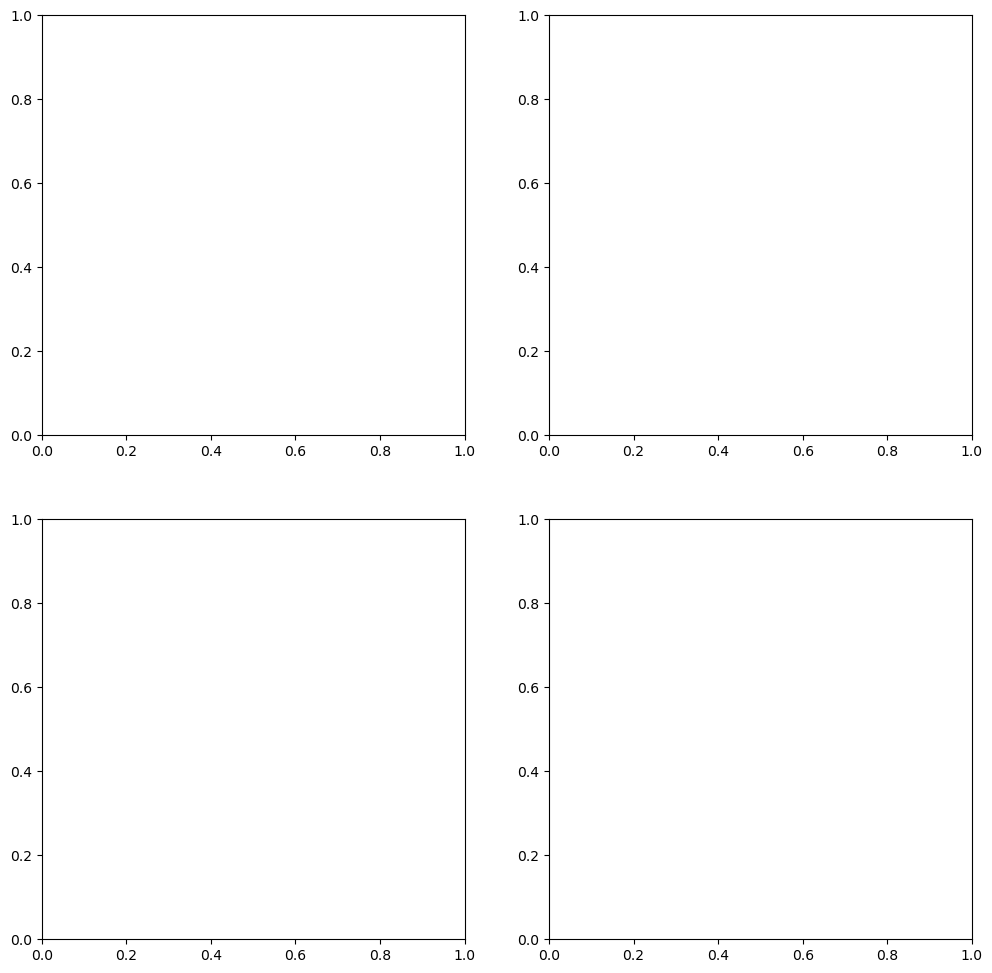

In [56]:
for start_node, end_node in df.groupby(["StartAt", "EndAt"]).groups.keys():
    plot_quartile_reebs_for_start_end(test_df, start_node, end_node)

['red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'yellow', 'yellow', 'yellow', 'yellow', 'blue', 'yellow', 'yellow', 'yellow', 'blue', 'blue', 'blue', 'green', 'yellow', 'yellow', 'green', 'yellow', 'blue', 'yellow', 'blue', 'yellow', 'yellow']


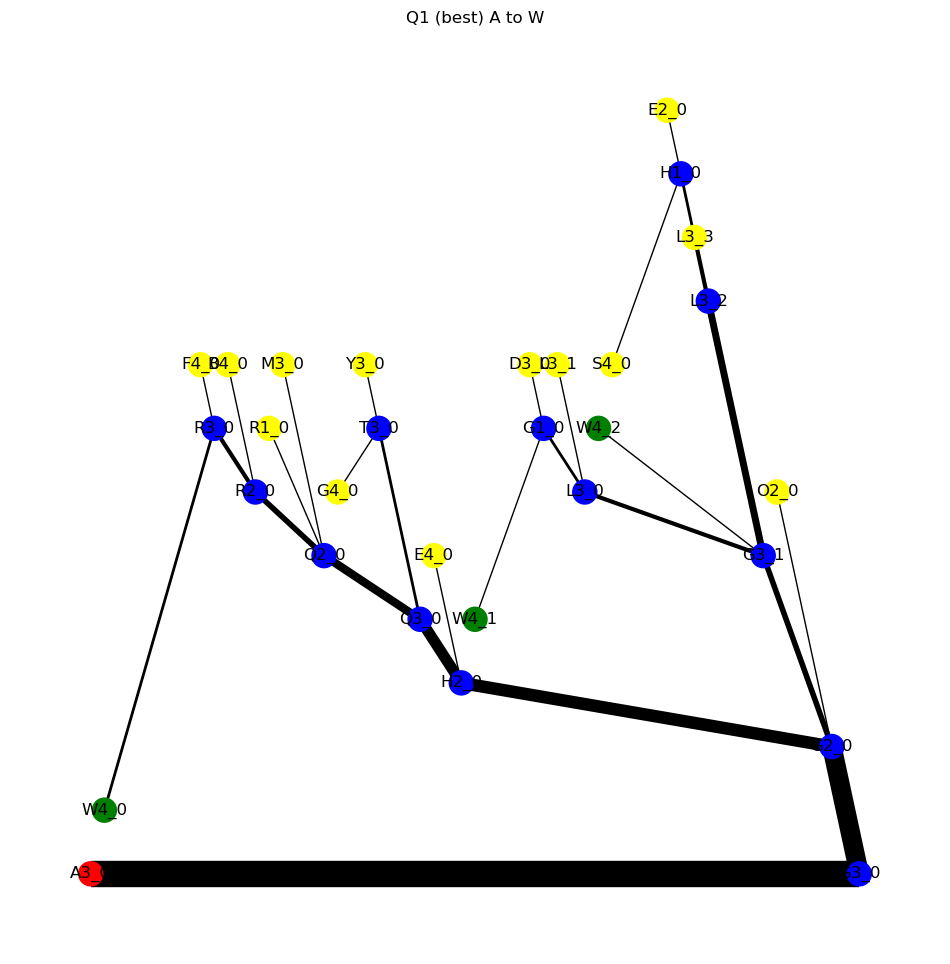

In [41]:
fig, ax = plt.subplots(figsize=(12,12))

# pos = nx.spectral_layout(G)
# pos = nx.shell_layout(G)
# pos = nx.spring_layout(G)
pos = nx.planar_layout(G)

edges = G.edges()
# colors = [G[u][v]['color'] for u,v in edges]
weights = [G[u][v]['weight'] for u,v in edges]

nodes = G.nodes()
# for n in nodes:
#     print(n, G.nodes[n])
n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
print(n_colors)

nx.draw(G, pos, width=weights, node_color=n_colors, with_labels=True, ax=ax)
plt.title(f"Q{Q} (best) A to W")
plt.show()